# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [38]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

G = 6.67*10**-11 #m^3/kg/s^2
ME = 5.9 * 10**24 #kg
MM = 7.3 * 10 ** 22 #kg
dEM = 3.8*10**8 #m
MA = 5500 #kg
m0 = 2.8 * 10**6 #kg
mf = 7.5 * 10**5 #kg
mdot = 1.3 * 10**4 #kg/s
es = 2.4 * 10**3 #m/s

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:
def gravPot (M:float, xM:float, yM:float, x:float, y:float) -> float:
    """ A function which calculates the gravitational potential given the distance from an object and the objects mass

    Args:
        M (float): mass of the object in kg
        xM (float): x-position of the object in meters
        yM (float): y-position of the object in meters
        x (float): x-position of the evaluation point in meters
        y (float): y-position of the evaluation point in meters

    Returns:
        float: the gravitational potential in J/kg
    """
    try:
        if (not isinstance(M, float) and not isinstance(M,int)) or (not isinstance(xM,float) and not isinstance(xM, int)) or (not isinstance(yM,float) and not isinstance(yM, float)) or (not isinstance(x,float) and not isinstance(x,int)) or (not isinstance(y,float) and not isinstance(y,int)):
            raise TypeError(f"At least one of the parameters is of the incorrect type.")
        elif M < 0:
            raise ValueError(f"Object has a recorded mass of less than 0.")
        elif x == xM and y == yM:
            raise ValueError(f"The object and evaluation point are the same, making the gravational potential NaN")
        else:
            if np.isclose(xM, x) and np.isclose(yM, y):
                return np.nan
            else:
                r = math.sqrt((x - xM)**2 + (y - yM)**2)
                pot = -1 * ((G*M)/r)
                return pot
                assert r > 0, "The computed radius is zero, making the gravitational potential NaN."
    except Exception as err:
        print(f"The code raised an error: {err}")

print (gravPot (1.0, 0.0, 0.0, 3.0, 4.0))
print (gravPot (2.0, 0.0,0.0,0.0,0.0))        
    

-1.334e-11
The code raised an error: The object and evaluation point are the same, making the gravational potential NaN
None


2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

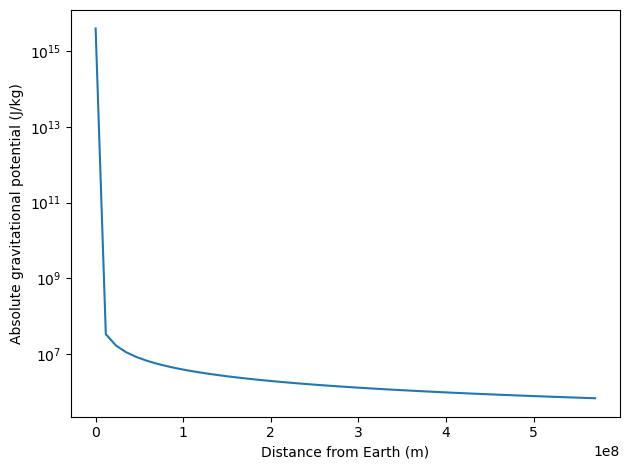

In [4]:
fig, ax = plt.subplots()
x = np.linspace(0.1, 1.5*dEM)
vgravPot = np.vectorize(gravPot)
y = np.abs(vgravPot(ME, 0.0, 0.0, x, 0.0))

ax.plot(x, y)
ax.set_yscale("log")
ax.set_xlabel("Distance from Earth (m)")
ax.set_ylabel("Absolute gravitational potential (J/kg)")

plt.tight_layout()


3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

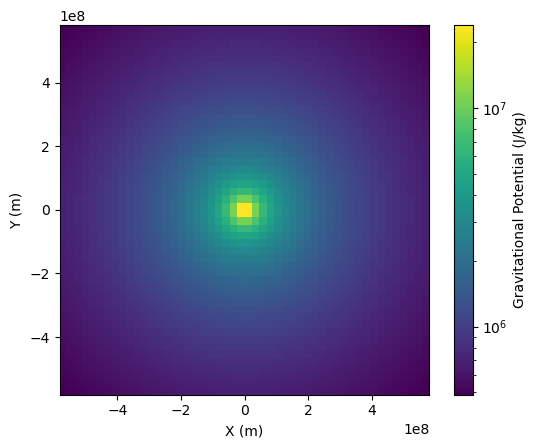

In [5]:
fig, ax = plt.subplots()
x = np.linspace(-1.5*dEM, 1.5*dEM)
y = np.linspace(-1.5*dEM, 1.5*dEM)
x_grid, y_grid = np.meshgrid(x,y)
z = np.abs(vgravPot(ME,0.0,0.0,x_grid,y_grid))
mesh = ax.pcolormesh(x_grid, y_grid, z, norm = "log", cmap = "viridis")
ax.set_aspect("equal")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
cbar = fig.colorbar(mesh)
cbar.set_label("Gravitational Potential (J/kg)")

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

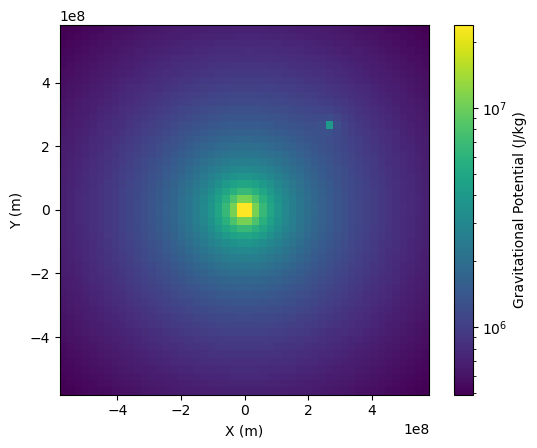

In [6]:
fig, ax = plt.subplots()
x = np.linspace(-1.5*dEM, 1.5*dEM)
y = np.linspace(-1.5*dEM, 1.5*dEM)
x_grid, y_grid = np.meshgrid(x,y)
epot = vgravPot(ME, 0.0, 0.0, x_grid, y_grid)
mpot = vgravPot(MM, dEM/math.sqrt(2), dEM/math.sqrt(2), x_grid, y_grid)
z = np.abs(epot + mpot)
mesh = ax.pcolormesh(x_grid, y_grid, z, norm = "log", cmap = "viridis")
ax.set_aspect("equal")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
cbar = fig.colorbar(mesh)
cbar.set_label("Gravitational Potential (J/kg)")

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

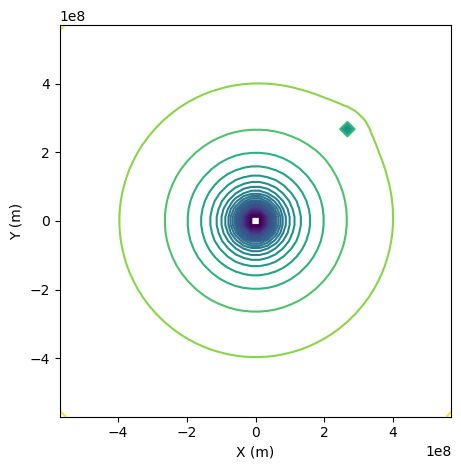

In [7]:
fig, ax = plt.subplots()
#custom_levels = np.linspace(5*10**7, 7*10**7, 10**9)
contour = ax.contour(x_grid, y_grid, z, norm = "log", cmap="viridis_r", levels = 50)
ax.set_aspect("equal")
#cbar = fig.colorbar(contour)
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
#cbar.set_label("Gravitational Potential (J/kg)")
fig.tight_layout()

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
def gravForce (M1, m2, x1, y1, x2, y2):
    """ A function which calculates the gravitational force components experienced by one mass from the force exerted by the other mass.

    Args:
        M1 (float): mass of the primary body in kg
        m2 (float): mass of the secondary body in kg
        x1 (float): x-position of the first object in meters
        y2 (float): y-position of the first object in meters
        x1 (float): x-position of the second object in meters
        y2 (float): y-position of the second object in meters

    Returns:
        float: the x-component of the gravitational force exerted on the second object by the first object.
        float: the y-component of the gravitational force exerted on the second object by the first object.
    """
    try:
        M1 = float(M1)
        m2 = float(m2)
        x1 = float(x1)
        y1 = float(y1)
        x2 = float(x2)
        y2 = float(y2)
        if not isinstance(M1, float) or not isinstance(m2,float) or not isinstance(x1,float) or not isinstance(y1,float) or not isinstance(x2,float) or not isinstance(y2, float):
            raise TypeError(f"At least one of the parameters is of the incorrect type.")
        elif M1 < 0 or m2 < 0:
            raise ValueError(f"At least one of the objects has a recorded mass of less than 0.")
        elif x1 == x2 and y1 == y2:
            raise ValueError(f"The object and evaluation point are the same, making the gravational force NaN")
        else:
            r = np.sqrt((x1-x2)**2+(y1-y2)**2)
            theta = math.atan((y2-y1)/(x2-x1))
            F = -1 * G * ((M1*m2)/(r**2))
            Fx = F * math.cos(theta)
            Fy = F * math.sin(theta)
            return Fx, Fy  
    except Exception as err:
         print(f"The code raised an error: {err}")   

gravForce(1, 1, 0, 0, 1, 0)

(np.float64(-6.67e-11), np.float64(-0.0))

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

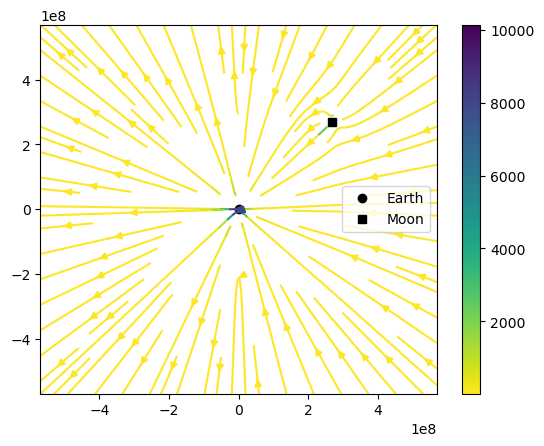

In [22]:
fig, ax = plt.subplots()
ax.plot([0], [0], "o", color='black', label = "Earth")
ax.plot([dEM/(np.sqrt(2))], [dEM/(np.sqrt(2))], "s", color='black', label = "Moon")
ax.legend()

x = np.linspace(-1.5 * dEM, 1.5 * dEM)
y = np.linspace(-1.5 * dEM, 1.5 * dEM)
X,Y = np.meshgrid(x,y)
vgravForce = np.vectorize(gravForce)
eForceX, eForceY = vgravForce(ME, MA, 0, 0, X, Y)
mForceX, mForceY = vgravForce(MM, MA, dEM/(math.sqrt(2)), dEM/(math.sqrt(2)), X, Y)
forceX = eForceX + mForceX
forceY = eForceY + mForceY
z = np.sqrt(np.square(forceX) + np.square(forceY**2))

stream = ax.streamplot(X, Y, forceX, forceY, color = np.sqrt(forceX**2 + forceY**2),  cmap="viridis_r")#, norm = "log")
cbar = fig.colorbar(stream.lines)

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

GME/x^2 = GMM/(x-dEM/sqrt(2))^2

ME/MM = x^2/(x-dEM/sqrt(2))^2

sqrt(ME/MM) = x/((x-dEM/sqrt(2))

(x-dEM/sqrt(2))/x = sqrt(MM/ME)

1-(dEM/x * sqrt(2)) = sqrt(MM/ME)

dEM/(x * sqrt(2)) = 1-sqrt(MM/ME)

dEM/(1-sqrt(MM/ME)) = x * sqrt(2)

x = (dEM / sqrt(2))/(1-sqrt(MM/ME))



y is calculated the same as x, y = (dEM / sqrt(2))/(1-sqrt(MM/ME))

And your updated plot, including the balance point, goes in the cell below.

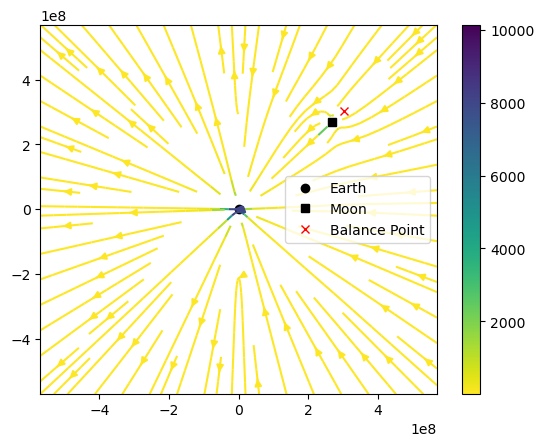

In [31]:
fig, ax = plt.subplots()
ax.plot([0], [0], "o", color='black', label = "Earth")
ax.plot([dEM/(np.sqrt(2))], [dEM/(np.sqrt(2))], "s", color='black', label = "Moon")
ax.plot([(dEM/np.sqrt(2))/(1-np.sqrt(MM/ME))], [(dEM/np.sqrt(2))/(1-np.sqrt(MM/ME))], "x", color='red', label = "Balance Point")
ax.legend()

x = np.linspace(-1.5 * dEM, 1.5 * dEM)
y = np.linspace(-1.5 * dEM, 1.5 * dEM)
X,Y = np.meshgrid(x,y)
vgravForce = np.vectorize(gravForce)
eForceX, eForceY = vgravForce(ME, MA, 0, 0, X, Y)
mForceX, mForceY = vgravForce(MM, MA, dEM/(math.sqrt(2)), dEM/(math.sqrt(2)), X, Y)
forceX = eForceX + mForceX
forceY = eForceY + mForceY
z = np.sqrt(np.square(forceX) + np.square(forceY**2))

stream = ax.streamplot(X, Y, forceX, forceY, color = np.sqrt(forceX**2 + forceY**2),  cmap="viridis_r")#, norm = "log")
cbar = fig.colorbar(stream.lines)

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

The balance point is close to the moon, but relatively far from Earth. This makes sense, because the Earth exerts more force on the sun, so the balance point should be closer to the moon. It does, however, seem odd to me that the balance point is not in between the Earth and the moon. There is likely a mistake in my calculations.

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [34]:
T = (m0 - mf)/mdot
print(T)

157.69230769230768


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [51]:
def deltav(t, m0, mf, mdot, T, es, g):
    """A function which calculates the change in velocity.

    Args:
    t (float): time in seconds
    m0 (float): wet (initial) mass in kg
    mf (float): dry (final) mass in kg
    mdot (float): burn rate in kg/second
    T (float): burn time in seconds
    es (float): exhaust speed in meters per second
    g (float): gravitational constant

    Returns:
    float: change in velocity in meters per second
    """
    try:
        t = float(t)
        m0 = float(m0)
        mf = float(mf)
        T = float(T)
        es = float(es)
        g = float(g)
        if not isinstance(t,float) or not isinstance(m0,float) or not isinstance(mf,float) or not isinstance(T,float) or not isinstance(es,float) or not isinstance(g,float):
            raise TypeError(f"At least one of the arguments is of the wrong type.")
        elif m0 <= 0:
            raise ValueError(f"The initial mass of the rocket should be greater than zero.")
        elif mf <= 0:
            raise ValueError(f"The final mass of the rocket should be greater than zero.")
        elif t < 0 or T < 0:
            raise ValueError(f"Neither of the time values should be negative.")
        else:
            if m0 == mf:
                return 0
            else:
                v = (es * math.log(m0/(m0 - (mdot * t)))) - (g*t)
                return v
    except Exception as err:
        print(f"The code raised an error: {err}")


print(deltav(12, m0, mf, mdot, T, es, -9.8))

255.18358846012393


3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [53]:
alt, err = quad(deltav, 0, T, args = (m0, mf, mdot, T, es, 9.8))
print(alt)

74218.31445319064


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

My calculated T was slightly lower than the T found in the testing data. The possibilities involve either human error or errors in the reported data. If the error is in the data it means either the wet mass I got was too low, or either the dry mass or the fuel burn rate I got was too high. It is also possible that the recorded burn time from the test data was not as precise as my calculations, and they cpuld only get two sig figs.


Since our burn times were different, it is lilely that both that difference and the difference in the variables that led to the difference in burn times are the main cause in our different altitudes.